In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import tensorflow as tf
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import pickle

In [4]:
df = pd.read_csv("Global_Health_Statistics.csv")

In [5]:
df.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007.0,...,7.58,Medication,21064.0,No,91.82,4493.0,2.16,16886.0,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318.0,...,5.11,Surgery,47851.0,Yes,76.65,2366.0,4.82,80639.0,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878.0,...,3.49,Vaccination,27834.0,Yes,98.55,41.0,5.81,12245.0,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224.0,...,8.44,Surgery,144.0,Yes,67.35,3201.0,2.22,49336.0,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908.0,...,5.90,Medication,8908.0,Yes,50.06,2832.0,6.93,47701.0,0.50,48.14


In [6]:
df.dtypes

,0
Country,object
Year,int64
Disease Name,object
Disease Category,object
Prevalence Rate (%),float64
Incidence Rate (%),float64
Mortality Rate (%),float64
Age Group,object
Gender,object
Population Affected,float64


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,163860.0,2012.017875,7.208431,2000.0,2006.00,2012.00,2018.00,2024.0
Prevalence Rate (%),163859.0,10.046885,5.734931,0.1,5.10,10.02,15.01,20.0
Incidence Rate (%),163859.0,7.566178,4.291924,0.1,3.86,7.57,11.29,15.0
Mortality Rate (%),163859.0,5.055638,2.861669,0.1,2.58,5.04,7.54,10.0
Population Affected,163859.0,500426.271746,288748.625469,1000.0,249942.00,500145.00,750891.50,999991.0
Healthcare Access (%),163859.0,74.989638,14.444618,50.0,62.41,75.01,87.49,100.0
Doctors per 1000,163859.0,2.746797,1.299253,0.5,1.62,2.75,3.87,5.0
Hospital Beds per 1000,163859.0,5.245383,2.741488,0.5,2.87,5.25,7.61,10.0
Average Treatment Cost (USD),163859.0,25021.119426,14403.083746,100.0,12570.50,24979.00,37497.00,50000.0
Recovery Rate (%),163859.0,74.532285,14.162577,50.0,62.25,74.52,86.80,99.0


In [8]:
df.head()

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
0,Italy,2013,Malaria,Respiratory,0.95,1.55,8.42,0-18,Male,471007.0,...,7.58,Medication,21064.0,No,91.82,4493.0,2.16,16886.0,0.79,86.02
1,France,2002,Ebola,Parasitic,12.46,8.63,8.75,61+,Male,634318.0,...,5.11,Surgery,47851.0,Yes,76.65,2366.0,4.82,80639.0,0.74,45.52
2,Turkey,2015,COVID-19,Genetic,0.91,2.35,6.22,36-60,Male,154878.0,...,3.49,Vaccination,27834.0,Yes,98.55,41.0,5.81,12245.0,0.41,40.20
3,Indonesia,2011,Parkinson's Disease,Autoimmune,4.68,6.29,3.99,0-18,Other,446224.0,...,8.44,Surgery,144.0,Yes,67.35,3201.0,2.22,49336.0,0.49,58.47
4,Italy,2013,Tuberculosis,Genetic,0.83,13.59,7.01,61+,Male,472908.0,...,5.90,Medication,8908.0,Yes,50.06,2832.0,6.93,47701.0,0.50,48.14


In [9]:
df.isnull().sum()

,0
Country,0
Year,0
Disease Name,1
Disease Category,1
Prevalence Rate (%),1
Incidence Rate (%),1
Mortality Rate (%),1
Age Group,1
Gender,1
Population Affected,1


In [10]:
df[df.isnull().any(axis=1)]

,Country,Year,Disease Name,Disease Category,Prevalence Rate (%),Incidence Rate (%),Mortality Rate (%),Age Group,Gender,Population Affected,...,Hospital Beds per 1000,Treatment Type,Average Treatment Cost (USD),Availability of Vaccines/Treatment,Recovery Rate (%),DALYs,Improvement in 5 Years (%),Per Capita Income (USD),Education Index,Urbanization Rate (%)
163859,South Korea,2013,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
df.dropna(inplace=True)

In [12]:
df.duplicated().any()

np.False_

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 163859 entries, 0 to 163858
Data columns (total 22 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   Country                             163859 non-null  object 
 1   Year                                163859 non-null  int64  
 2   Disease Name                        163859 non-null  object 
 3   Disease Category                    163859 non-null  object 
 4   Prevalence Rate (%)                 163859 non-null  float64
 5   Incidence Rate (%)                  163859 non-null  float64
 6   Mortality Rate (%)                  163859 non-null  float64
 7   Age Group                           163859 non-null  object 
 8   Gender                              163859 non-null  object 
 9   Population Affected                 163859 non-null  float64
 10  Healthcare Access (%)               163859 non-null  float64
 11  Doctors per 1000               

In [ ]:
label_encoder = LabelEncoder()
categorical_cols = ["Disease Category", "Disease Name", "Treatment Type", "Country"]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

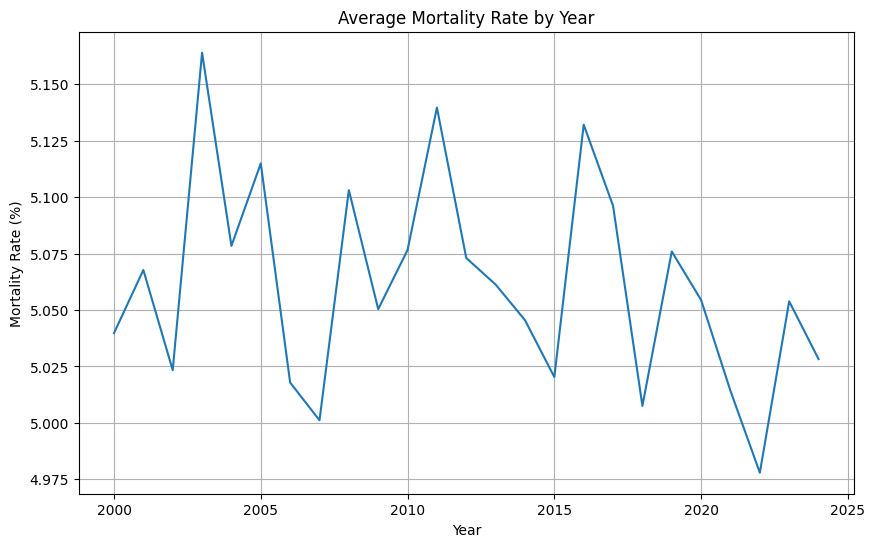

In [ ]:
yil_mortalite = df.groupby("Year")["Mortality Rate (%)"].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=yil_mortalite, x="Year", y="Mortality Rate (%)")
plt.title("Average Mortality Rate by Year")
plt.ylabel("Mortality Rate (%)")
plt.grid(True)
plt.show()

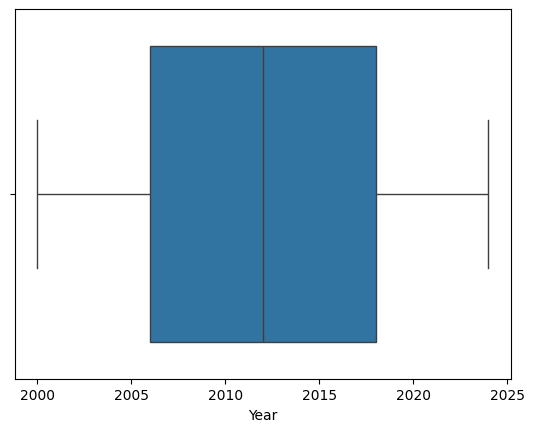

In [ ]:
sns.boxplot(x=df["Year"])
plt.show()

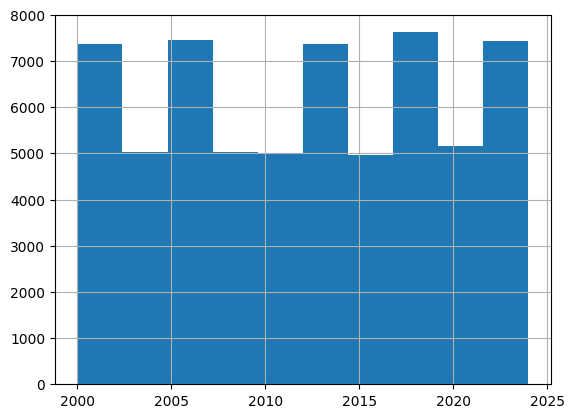

In [ ]:
df["Year"].hist()
plt.show()

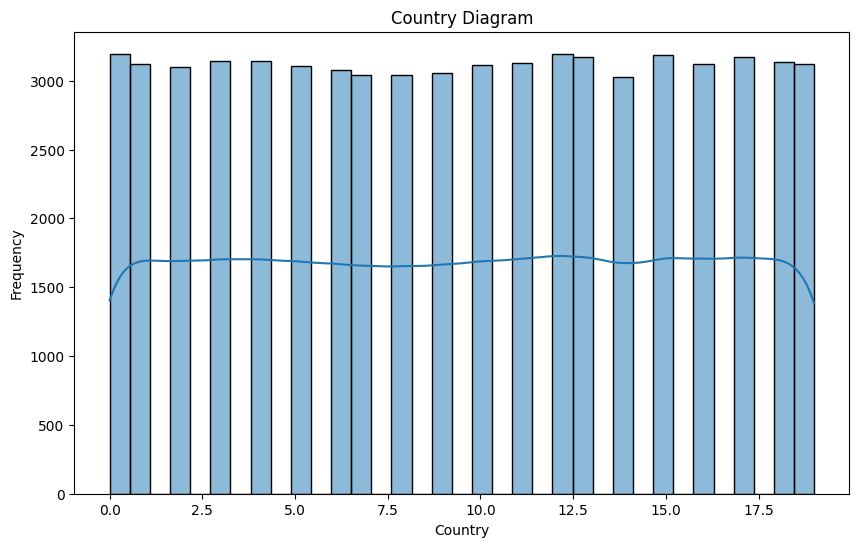

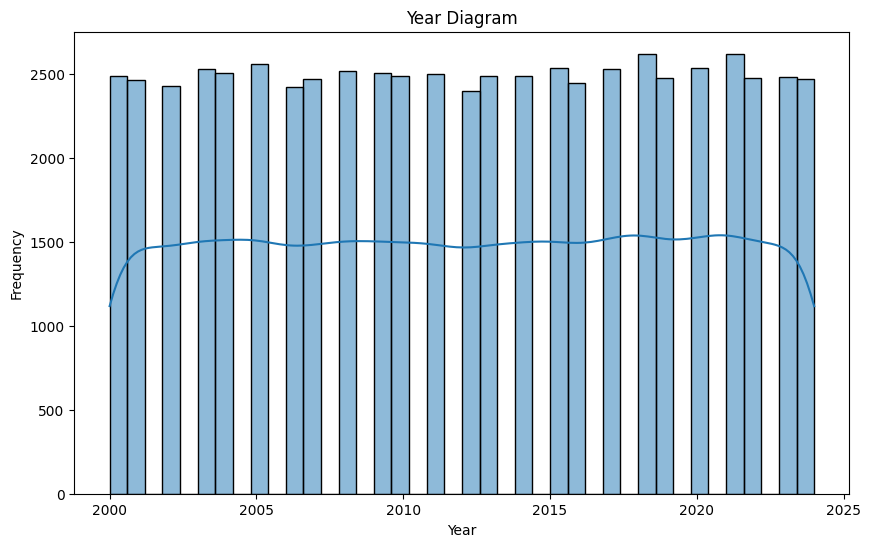

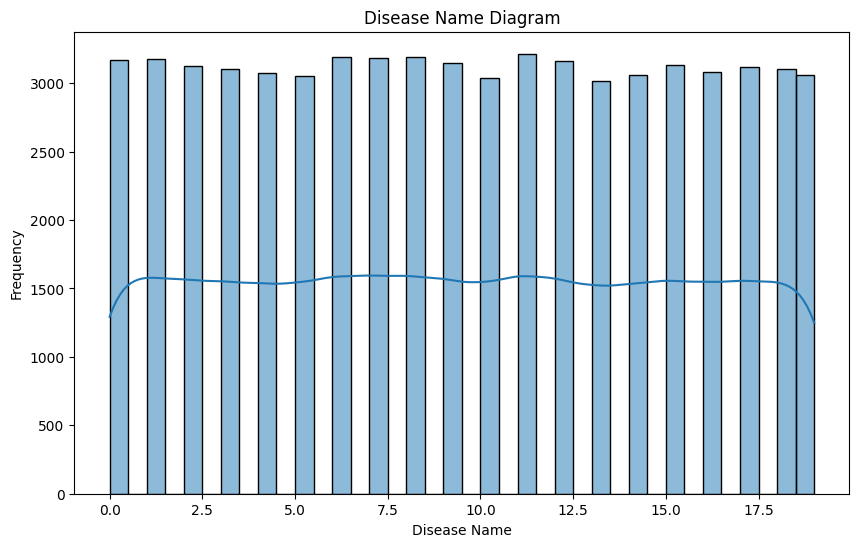

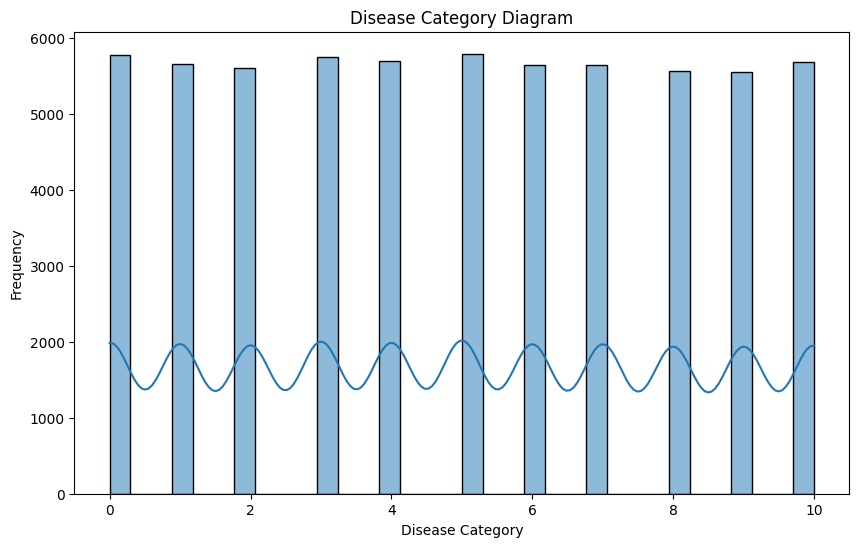

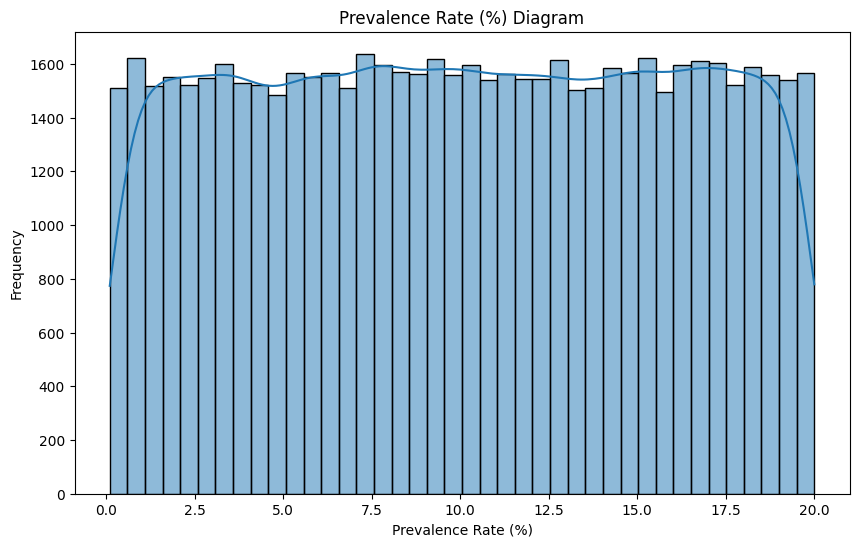

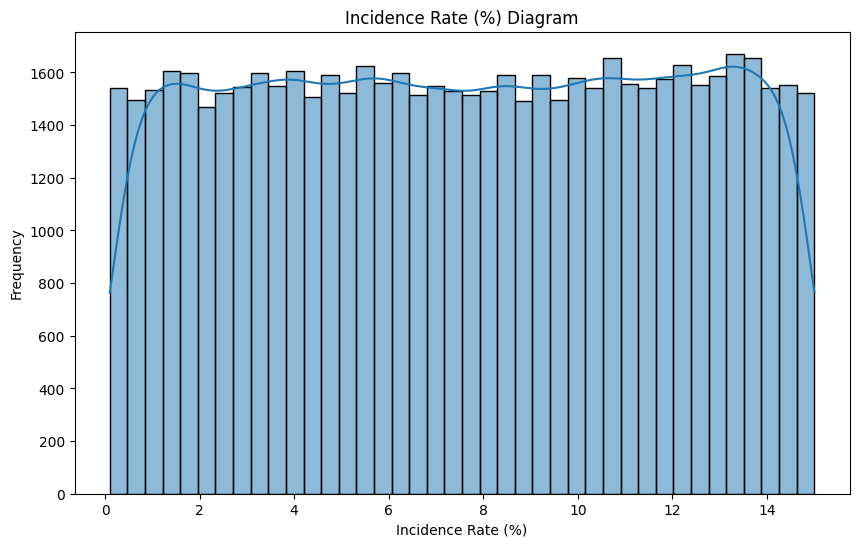

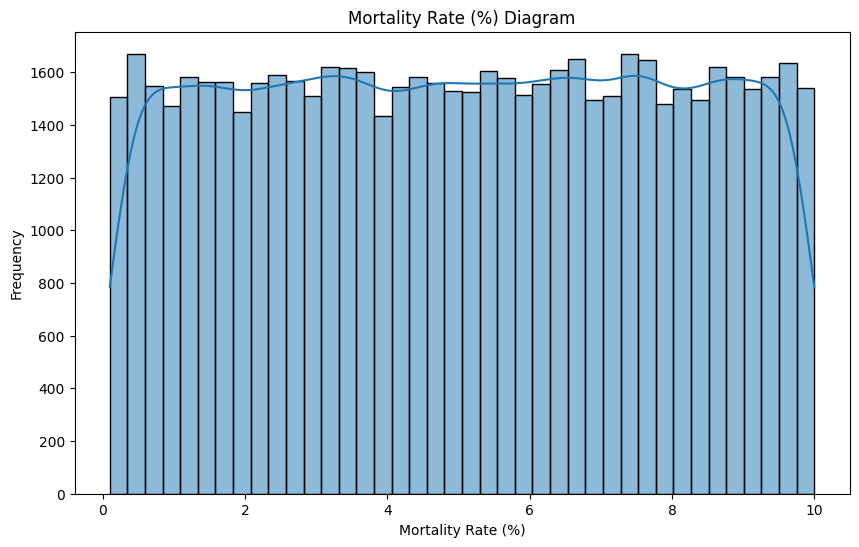

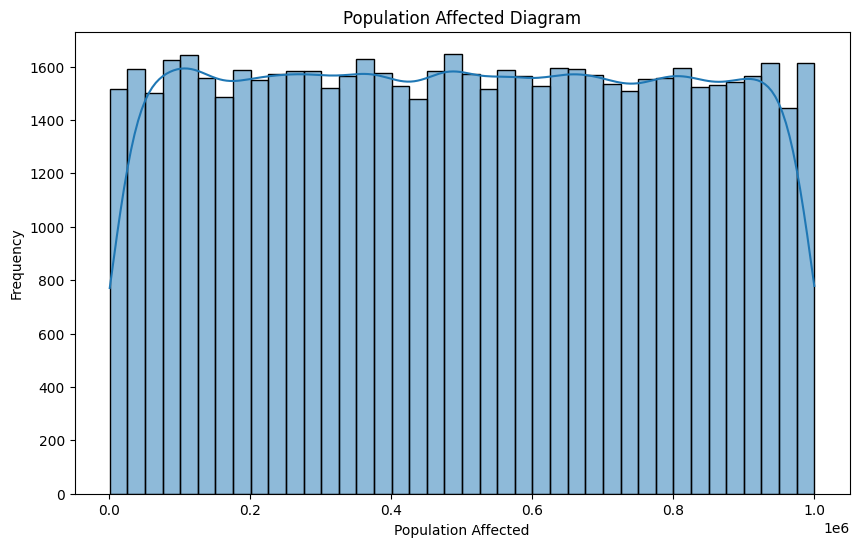

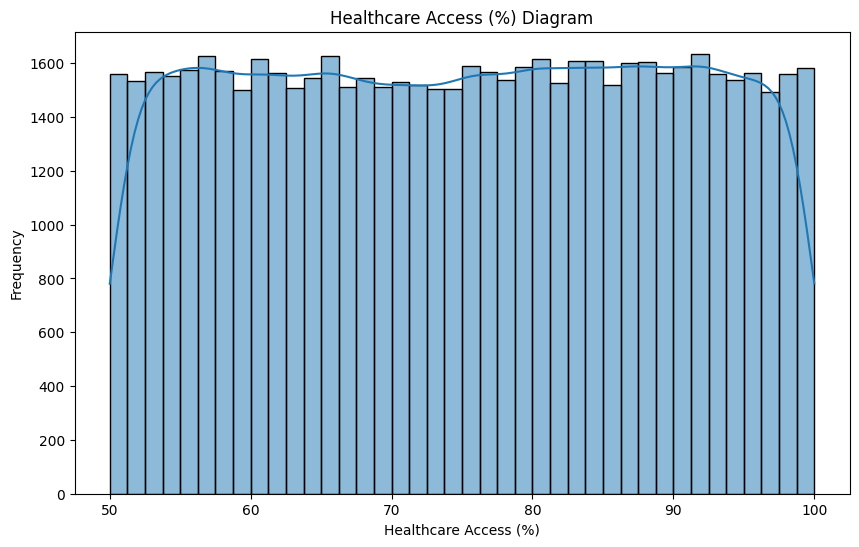

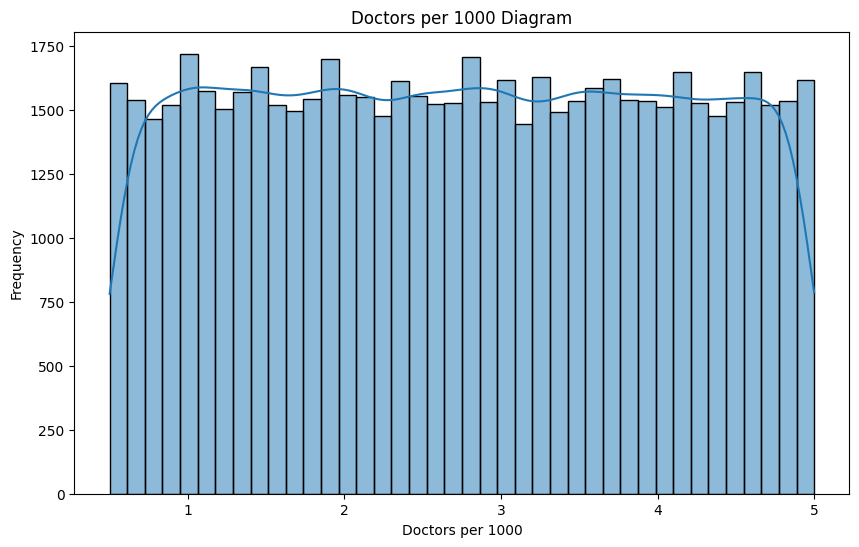

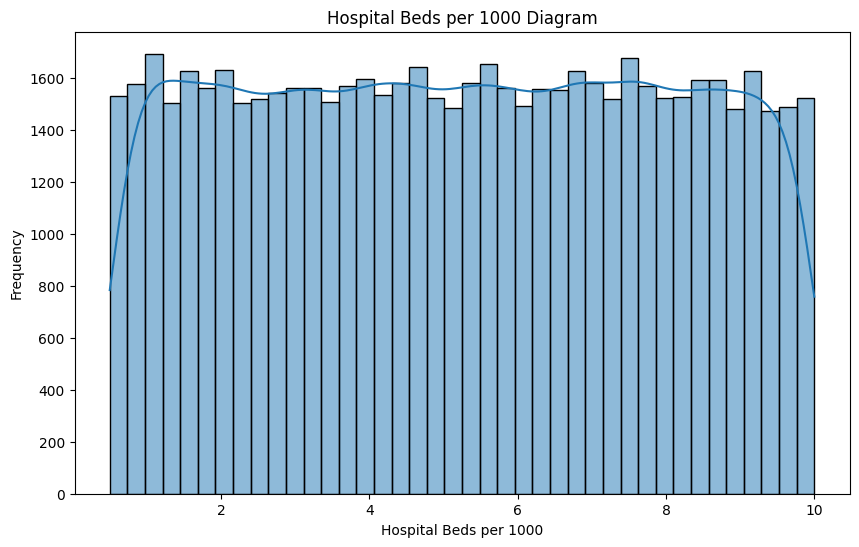

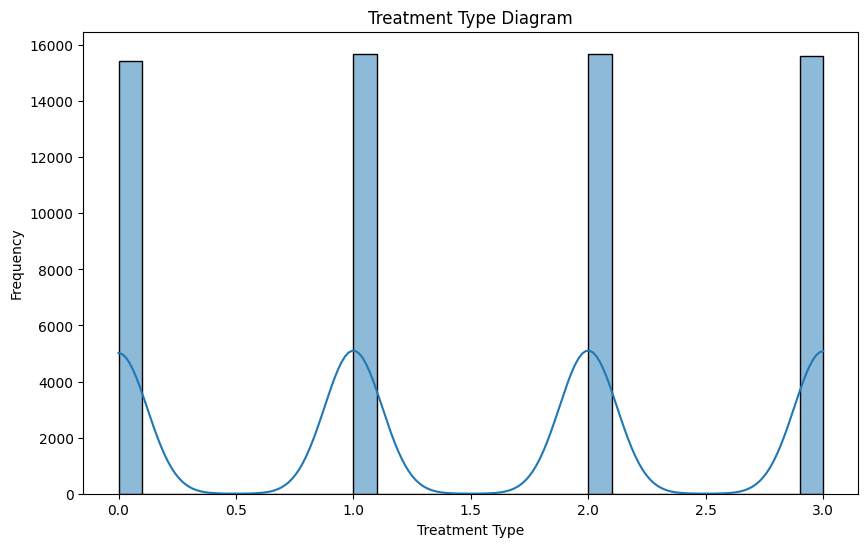

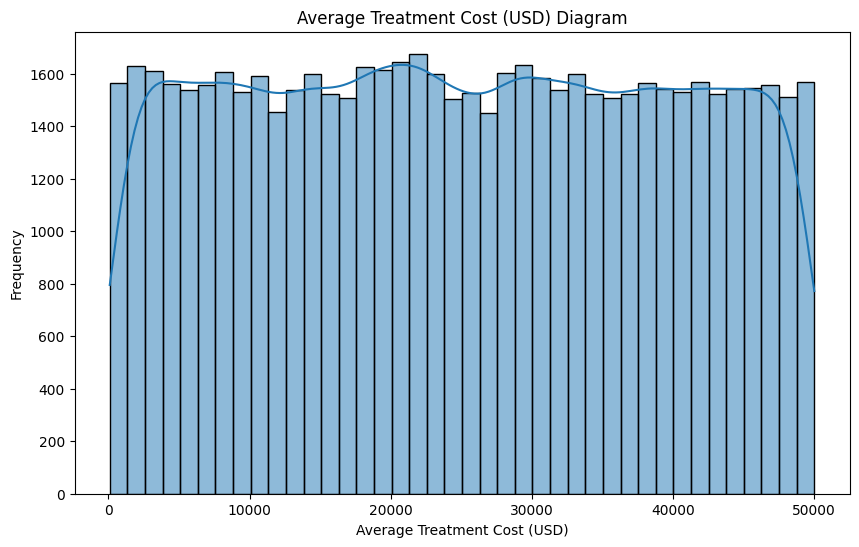

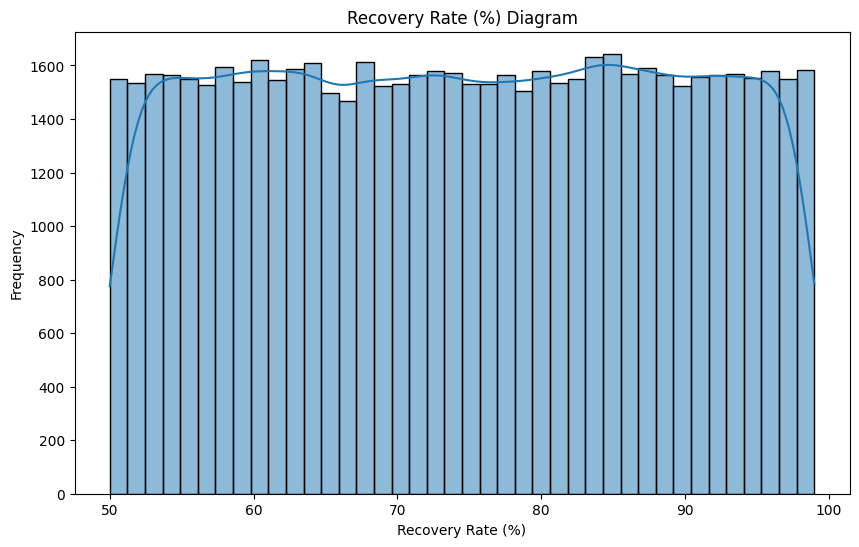

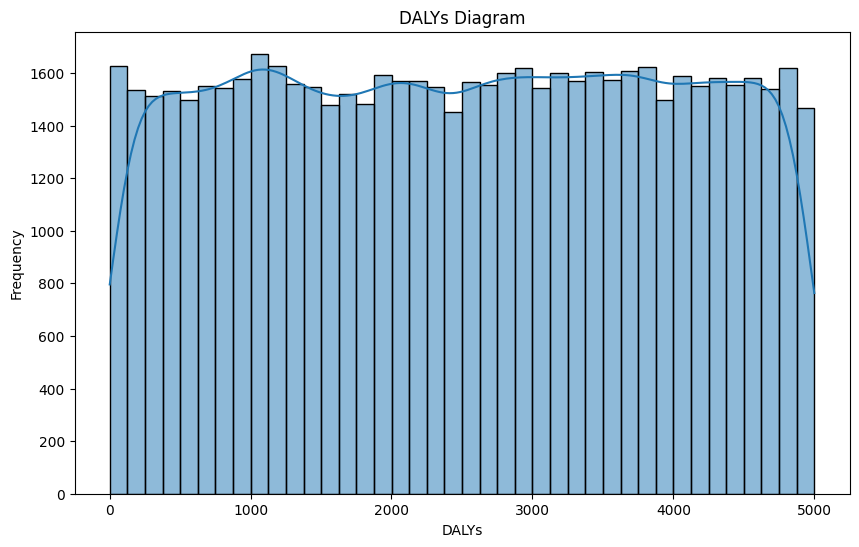

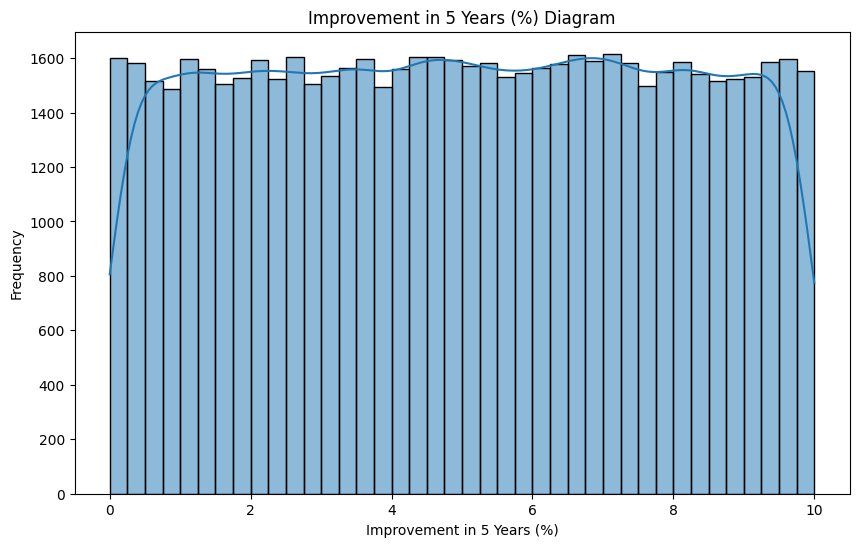

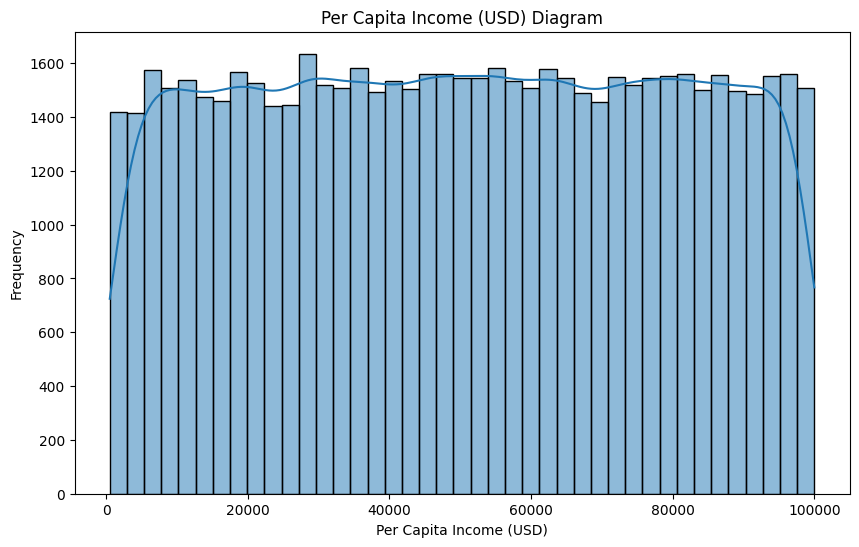

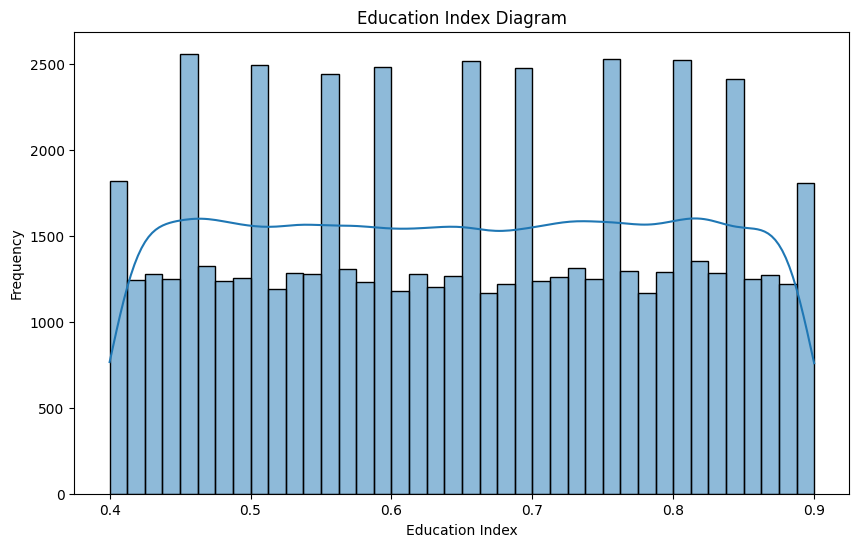

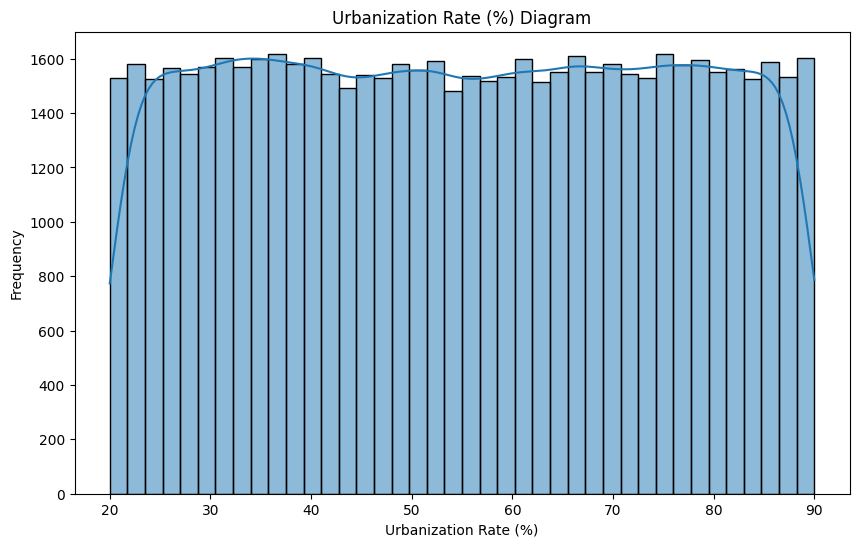

In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns

for col in num_cols:
    plt.figure(figsize=(10,6))
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} Diagram")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
corr_vars = ["Mortality Rate (%)", "Recovery Rate (%)", "Doctors per 1000",
             "Hospital Beds per 1000", "Healthcare Access (%)",
             "Per Capita Income (USD)", "Education Index", "Urbanization Rate (%)"]

corr_matrix = df[corr_vars].corr()

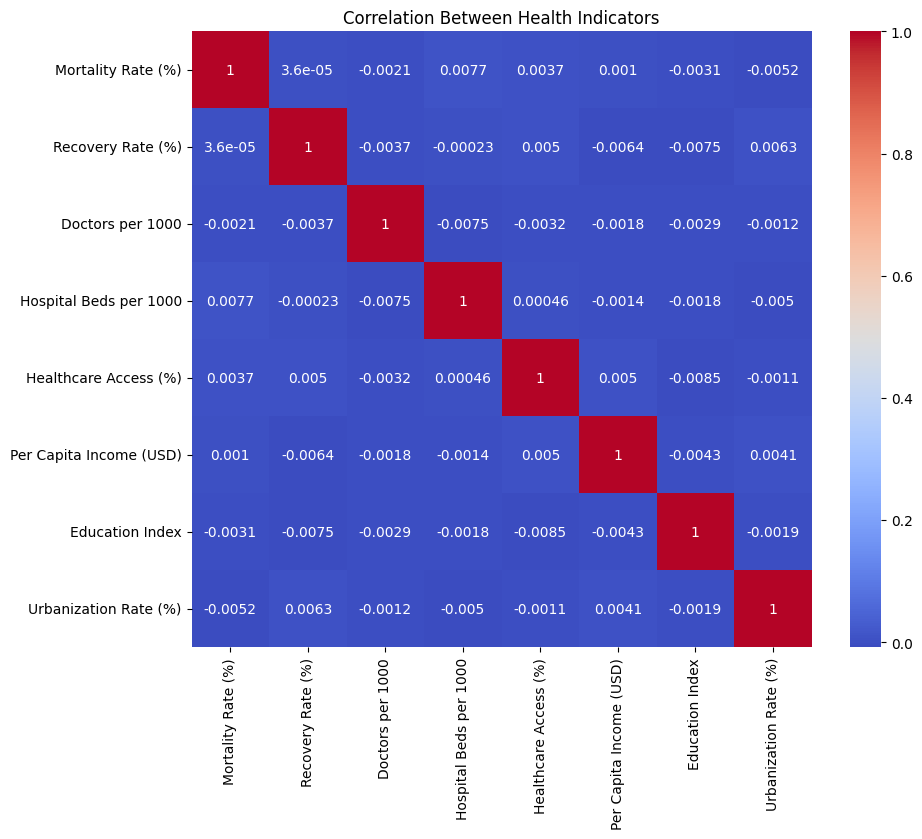

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Between Health Indicators")
plt.show()

In [ ]:
X = df[[
    "Year",
    "Country",
    "Disease Category",
    "Disease Name",
    "Treatment Type",
    "Doctors per 1000",
    "Per Capita Income (USD)",
    "Education Index",
    "Urbanization Rate (%)"
]]

Y = df[[
    "Mortality Rate (%)",
    "Recovery Rate (%)",
    "Healthcare Access (%)",
    "Hospital Beds per 1000"
]]

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
models = {
    "Random Forest": MultiOutputRegressor(RandomForestRegressor(random_state=42)),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(random_state=42, eval_metric='rmse')),
    "LightGBM": MultiOutputRegressor(LGBMRegressor(random_state=42))
}

In [ ]:
for name, model in models.items():
    print("======================================================================")
    print(f"Model: {name}")
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)


    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)
    medae = median_absolute_error(y_test, y_pred)


    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"MAE: {mae}")
    print(f"MAPE: {mape}%")
    print(f"Median AE: {medae}")
    print(f"R^2: {r2}")

Model: Random Forest
MSE: 109.42234991386394
RMSE: 10.460513845594008
MAE: 7.502850224323026
MAPE: 75.84270282633237%
Median AE: 7.444625000000001
R^2: -0.024920489762041143
Model: Gradient Boosting
MSE: 106.85092072149749
RMSE: 10.336871902151902
MAE: 7.436871307028198
MAPE: 75.63597242429621%
Median AE: 7.436063141118175
R^2: -0.0018120101841799796
Model: XGBoost
MSE: 112.54169464111328
RMSE: 10.608567039949989
MAE: 7.575028419494629
MAPE: 76.07787462065924%
Median AE: 7.469553151130676
R^2: -0.05222207307815552
Model: LightGBM
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001938 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 899
[LightGBM] [Info] Number of data points in the train set: 49928, number of used features: 9
[LightGBM] [Info] Start training from score 5.060498
[LightGBM] [Info] Auto-choosing col-wise multi-threading, th

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


MSE: 107.31229841702516
RMSE: 10.3591649478626
MAE: 7.450449728221862
MAPE: 75.77400598094968%
Median AE: 7.4379138080929
R^2: -0.0060196835361781


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
final_model = models["Random Forest"]

with open("multi_output_model.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("✅ Model training complete. Multi-output model saved as 'multi_output_model.pkl'.")

KeyboardInterrupt: 